Using device: cpu
Directories created: artifacts/figures
Number of observations: 4320
Date range: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Missing values:
 date      0
target    0
dtype: int64


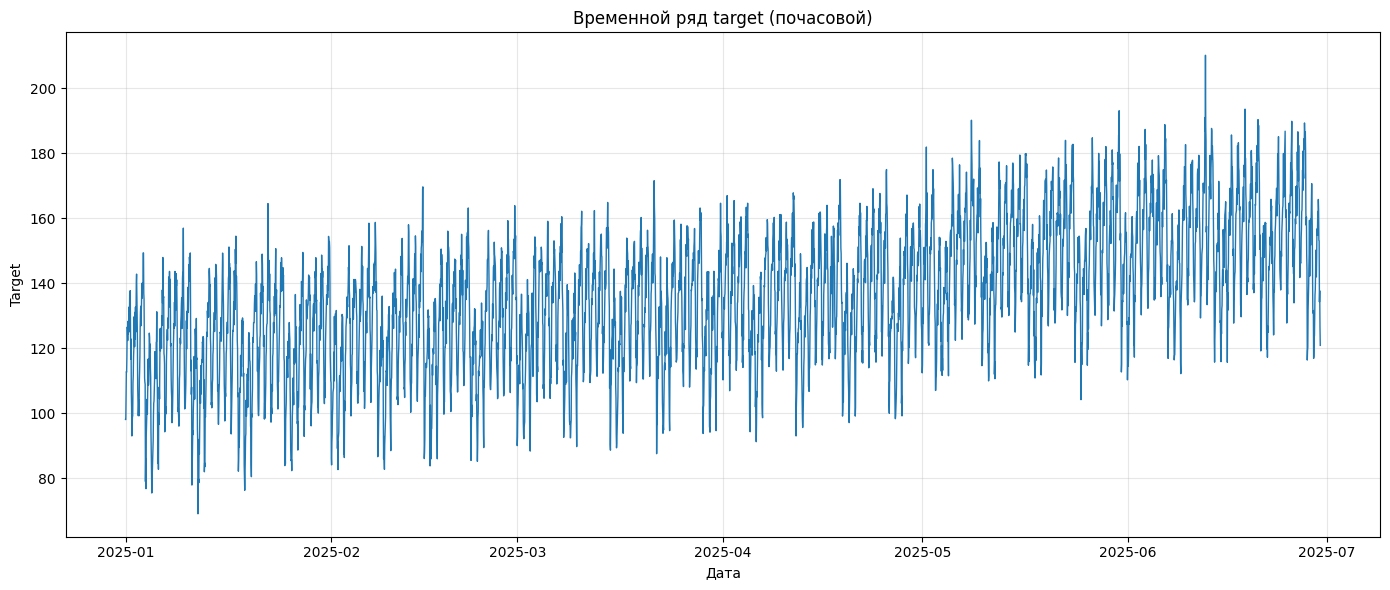


Комментарий к ряду:
- Почасовые данные за ~180 дней (4320 наблюдений).
- Есть восходящий тренд и сильная суточная + недельная сезонность.
- Значения колеблются примерно от 70 до 210.
- Ряд нестационарный → нужны лаговые, rolling и календарные признаки.

Train: 3456 obs (2025-01-01 00:00:00 — 2025-05-24 23:00:00)
Val:   432 obs (2025-05-25 00:00:00 — 2025-06-11 23:00:00)
Test:  432 obs (2025-06-12 00:00:00 — 2025-06-29 23:00:00)


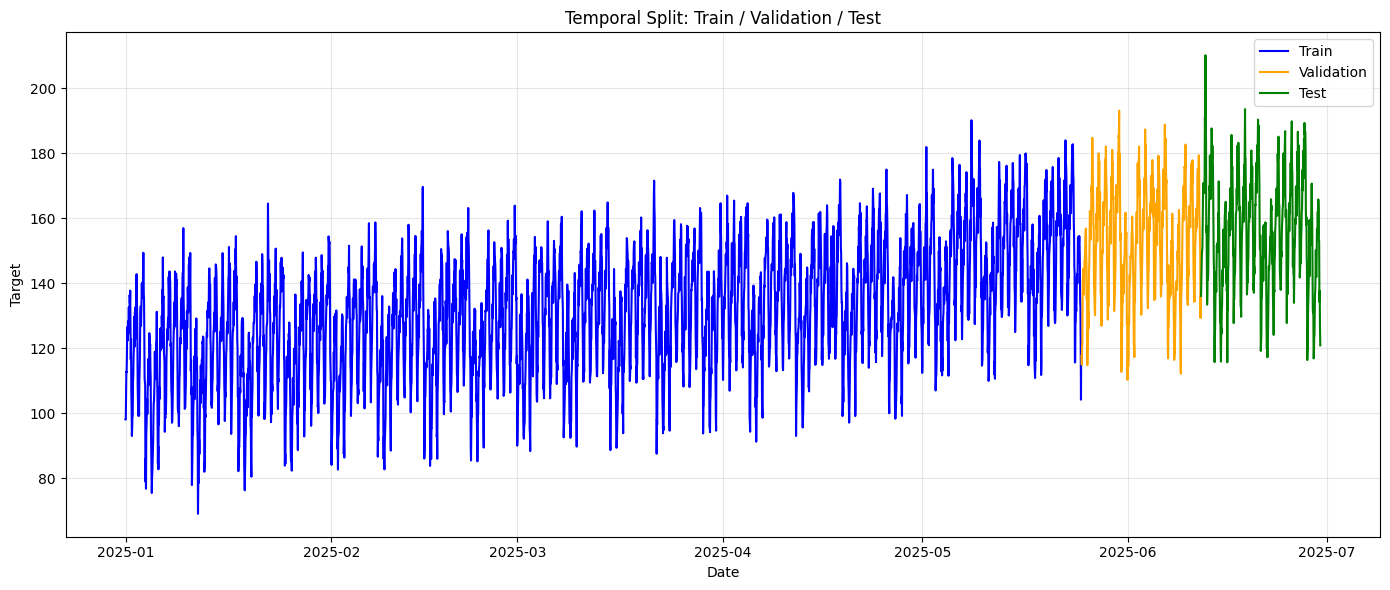


Почему random split некорректен:
• Нарушает временную зависимость и вызывает data leakage из будущего.
• Модель будет переоценивать качество, т.к. 'увидит' будущие значения во время обучения.
Features prepared. X_train shape: (3442, 8)
Training GRU...
Epoch 10 | Train Loss: 0.7830 | Val MAE: 12.4422
Epoch 20 | Train Loss: 0.7742 | Val MAE: 12.7463
Epoch 30 | Train Loss: 0.7682 | Val MAE: 12.9918
Epoch 40 | Train Loss: 0.7654 | Val MAE: 13.1627
Epoch 50 | Train Loss: 0.7630 | Val MAE: 13.3055
Epoch 60 | Train Loss: 0.7613 | Val MAE: 13.3953
runs.csv saved

Лучшая модель по val MAE: B3
best_gru.pt saved
best_gru_config.json saved
Test metrics for best model (B3): MAE=5.3237, RMSE=6.9183, MAPE=3.46%


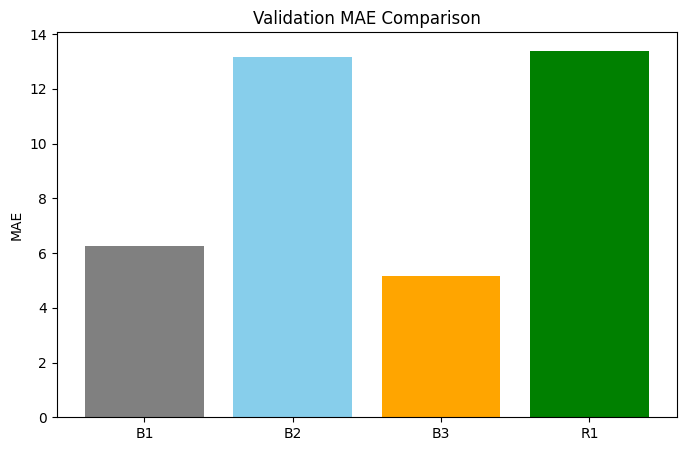

baselines_compare.png saved


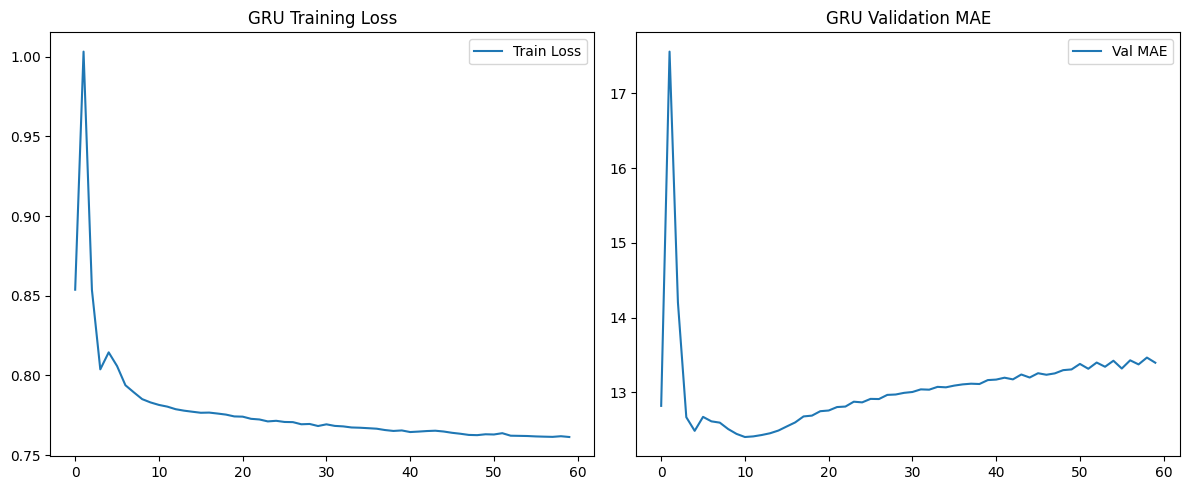

gru_learning_curves.png saved


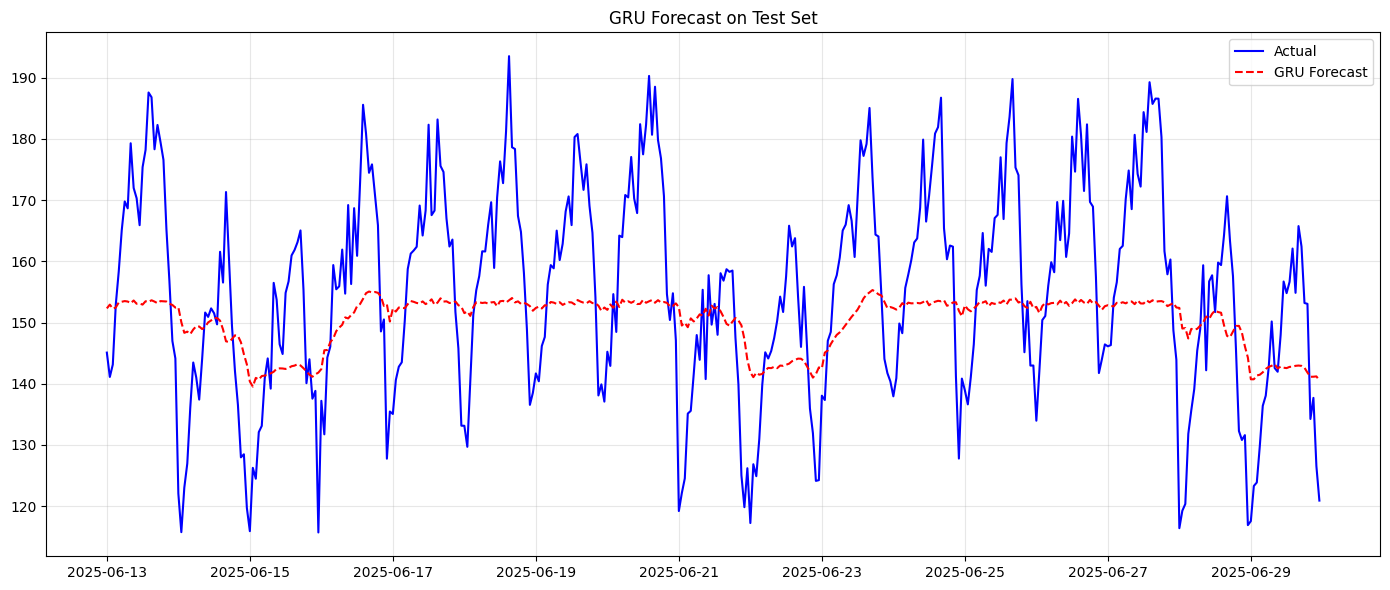

best_forecast_test.png saved

Все артефакты успешно сохранены!

Сохраненные файлы:
  - artifacts/runs.csv
  - artifacts/best_gru.pt
  - artifacts/best_gru_config.json
  - artifacts/figures/initial_series.png
  - artifacts/figures/series_split.png
  - artifacts/figures/baselines_compare.png
  - artifacts/figures/gru_learning_curves.png
  - artifacts/figures/best_forecast_test.png


In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# =============================================
# 1. Импорты, seed и устройство
# =============================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Создаём папки для артефактов
os.makedirs('artifacts/figures', exist_ok=True)
print("Directories created: artifacts/figures")

# =============================================
# 2. Данные и первичный анализ
# =============================================
df = pd.read_csv('S12-hw-dataset.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Number of observations: {len(df)}")
print(f"Date range: {df['date'].min()} — {df['date'].max()}")
print("\nMissing values:\n", df.isnull().sum())

# Базовый график
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['target'], linewidth=1)
plt.title('Временной ряд target (почасовой)')
plt.xlabel('Дата')
plt.ylabel('Target')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/initial_series.png')
plt.show()

print("\nКомментарий к ряду:")
print("- Почасовые данные за ~180 дней (4320 наблюдений).")
print("- Есть восходящий тренд и сильная суточная + недельная сезонность.")
print("- Значения колеблются примерно от 70 до 210.")
print("- Ряд нестационарный → нужны лаговые, rolling и календарные признаки.")

# =============================================
# 3. Temporal split (80/10/10)
# =============================================
n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"\nTrain: {len(train_df)} obs ({train_df['date'].min()} — {train_df['date'].max()})")
print(f"Val:   {len(val_df)} obs ({val_df['date'].min()} — {val_df['date'].max()})")
print(f"Test:  {len(test_df)} obs ({test_df['date'].min()} — {test_df['date'].max()})")

# Визуализация split
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange')
plt.plot(test_df['date'], test_df['target'], label='Test', color='green')
plt.title('Temporal Split: Train / Validation / Test')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png')
plt.show()

print("\nПочему random split некорректен:")
print("• Нарушает временную зависимость и вызывает data leakage из будущего.")
print("• Модель будет переоценивать качество, т.к. 'увидит' будущие значения во время обучения.")

# =============================================
# 4. Признаки для baseline-моделей (без утечки!)
# =============================================
def create_features(df):
    df = df.copy()
    # Лаги
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    # Rolling
    df['rolling_mean_7'] = df['target'].rolling(window=7).mean()
    df['rolling_std_7'] = df['target'].rolling(window=7).std()
    # Календарные
    df['day_of_week'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    df['month'] = df['date'].dt.month
    
    df = df.dropna().reset_index(drop=True)
    return df

train_feat = create_features(train_df)
val_feat   = create_features(val_df)
test_feat  = create_features(test_df)

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'day_of_week', 'hour', 'month']

X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values
X_val   = val_feat[feature_cols].values
y_val   = val_feat['target'].values
X_test  = test_feat[feature_cols].values
y_test  = test_feat['target'].values

# Масштабирование только на train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Features prepared. X_train shape: {X_train.shape}")

# =============================================
# 5. Dataset и DataLoader для GRU
# =============================================
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size=24, horizon=1):
        self.data = data
        self.window_size = window_size
        self.horizon = horizon
        
    def __len__(self):
        return len(self.data) - self.window_size - self.horizon + 1
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size:idx + self.window_size + self.horizon]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor(y).unsqueeze(-1)

WINDOW_SIZE = 24
HORIZON = 1
BATCH_SIZE = 64

target_scaler = StandardScaler()
target_scaler.fit(train_df['target'].values.reshape(-1, 1))

train_scaled = target_scaler.transform(train_df['target'].values.reshape(-1, 1)).flatten()
val_scaled   = target_scaler.transform(val_df['target'].values.reshape(-1, 1)).flatten()
test_scaled  = target_scaler.transform(test_df['target'].values.reshape(-1, 1)).flatten()

train_dataset = TimeSeriesDataset(train_scaled, WINDOW_SIZE, HORIZON)
val_dataset   = TimeSeriesDataset(val_scaled,   WINDOW_SIZE, HORIZON)
test_dataset  = TimeSeriesDataset(test_scaled,  WINDOW_SIZE, HORIZON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# =============================================
# 6. Модель GRU + функции обучения
# =============================================
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device, scaler=None):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            output = model(x)
            preds.append(output.cpu().numpy())
            targets.append(y.numpy())
    
    preds = np.concatenate(preds, axis=0).reshape(-1, 1)
    targets = np.concatenate(targets, axis=0).reshape(-1, 1)
    
    if scaler:
        preds = scaler.inverse_transform(preds)
        targets = scaler.inverse_transform(targets)
    
    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mape = np.mean(np.abs((targets - preds) / (targets + 1e-8))) * 100
    return mae, rmse, mape

# =============================================
# 7. Эксперименты B1–B3, R1
# =============================================
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

# B1: Naive Last
y_pred_b1 = np.roll(y_val, 1)
y_pred_b1[0] = y_val[0]
mae_b1, rmse_b1, mape_b1 = calc_metrics(y_val, y_pred_b1)

# B2: Moving Average
window_ma = 24
y_pred_b2 = pd.Series(y_val).rolling(window=window_ma, min_periods=1).mean().values
mae_b2, rmse_b2, mape_b2 = calc_metrics(y_val, y_pred_b2)

# B3: Ridge
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_scaled, y_train)
y_pred_b3 = ridge.predict(X_val_scaled)
mae_b3, rmse_b3, mape_b3 = calc_metrics(y_val, y_pred_b3)

# R1: GRU
model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_mae = float('inf')
best_state = None
train_losses, val_maes = [], []

print("Training GRU...")
for epoch in range(60):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_mae, val_rmse, val_mape = evaluate(model, val_loader, criterion, device, target_scaler)
    
    train_losses.append(train_loss)
    val_maes.append(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = model.state_dict().copy()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Val MAE: {val_mae:.4f}")

model.load_state_dict(best_state)
val_mae_r1, val_rmse_r1, val_mape_r1 = evaluate(model, val_loader, criterion, device, target_scaler)

# =============================================
# 8. Сохранение результатов в runs.csv
# =============================================
results = pd.DataFrame([
    {'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
     'seed': SEED, 'split_summary': '80/10/10 temporal', 'window_size': None,
     'horizon': 1, 'model_summary': 'Naive Last', 'features_summary': 'None',
     'scaler': 'None', 'optimizer': 'None', 'lr': None, 'epochs_trained': 0,
     'best_val_mae': mae_b1, 'best_val_rmse': rmse_b1, 'best_val_mape': mape_b1,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': 'Последнее значение'},
    
    {'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
     'seed': SEED, 'split_summary': '80/10/10 temporal', 'window_size': window_ma,
     'horizon': 1, 'model_summary': 'Moving Average', 'features_summary': 'None',
     'scaler': 'None', 'optimizer': 'None', 'lr': None, 'epochs_trained': 0,
     'best_val_mae': mae_b2, 'best_val_rmse': rmse_b2, 'best_val_mape': mape_b2,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': f'Rolling mean window={window_ma}'},
    
    {'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
     'seed': SEED, 'split_summary': '80/10/10 temporal', 'window_size': None,
     'horizon': 1, 'model_summary': 'Ridge', 
     'features_summary': 'lags + rolling + calendar',
     'scaler': 'StandardScaler', 'optimizer': 'None', 'lr': None, 'epochs_trained': 0,
     'best_val_mae': mae_b3, 'best_val_rmse': rmse_b3, 'best_val_mape': mape_b3,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': 'Ridge on engineered features'},
    
    {'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
     'seed': SEED, 'split_summary': '80/10/10 temporal', 'window_size': WINDOW_SIZE,
     'horizon': 1, 'model_summary': 'GRU (64, 2 layers)', 
     'features_summary': 'windowed target only',
     'scaler': 'StandardScaler', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': 60,
     'best_val_mae': val_mae_r1, 'best_val_rmse': val_rmse_r1, 'best_val_mape': val_mape_r1,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': 'GRU window=24'}
])

results.to_csv('artifacts/runs.csv', index=False)
print("runs.csv saved")

# =============================================
# 9. Выбор лучшей модели + оценка на test
# =============================================
best_row = results.loc[results['best_val_mae'].idxmin()]
best_id = best_row['experiment_id']
print(f"\nЛучшая модель по val MAE: {best_id}")

# Всегда сохраняем GRU модель и конфиг (если R1 - лучшая, то сохраняем её, иначе сохраняем всё равно для отчета)
# Сохраняем лучшую GRU
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
print("best_gru.pt saved")

config = {
    "model": "GRU",
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "window_size": WINDOW_SIZE,
    "batch_size": BATCH_SIZE,
    "lr": 0.001,
    "seed": SEED,
    "scaler": "StandardScaler"
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("best_gru_config.json saved")

if best_id == 'R1':
    test_mae, test_rmse, test_mape = evaluate(model, test_loader, criterion, device, target_scaler)
else:
    # Для baseline'ов просто считаем на test
    if best_id == 'B1':
        pred_test = np.roll(y_test, 1)
        pred_test[0] = y_test[0]
    elif best_id == 'B2':
        pred_test = pd.Series(y_test).rolling(window=window_ma, min_periods=1).mean().values
    else:  # B3
        pred_test = ridge.predict(X_test_scaled)
    test_mae, test_rmse, test_mape = calc_metrics(y_test, pred_test)

# Записываем test метрики
results.loc[results['experiment_id'] == best_id, ['test_mae', 'test_rmse', 'test_mape']] = [test_mae, test_rmse, test_mape]
results.to_csv('artifacts/runs.csv', index=False)

print(f"Test metrics for best model ({best_id}): MAE={test_mae:.4f}, RMSE={test_rmse:.4f}, MAPE={test_mape:.2f}%")

# =============================================
# 10. Визуализации (все требуемые)
# =============================================
# Сравнение на валидации
plt.figure(figsize=(8,5))
plt.bar(results['experiment_id'], results['best_val_mae'], color=['gray','skyblue','orange','green'])
plt.title('Validation MAE Comparison')
plt.ylabel('MAE')
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()
print("baselines_compare.png saved")

# Кривые обучения GRU
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.title('GRU Training Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(val_maes, label='Val MAE')
plt.title('GRU Validation MAE')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()
print("gru_learning_curves.png saved")


model.eval()
preds, targets = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        preds.append(out.cpu().numpy())
        targets.append(y.numpy())
preds = np.concatenate(preds).reshape(-1,1)
targets = np.concatenate(targets).reshape(-1,1)
preds = target_scaler.inverse_transform(preds)
targets = target_scaler.inverse_transform(targets)

test_dates = test_df['date'].iloc[WINDOW_SIZE:].reset_index(drop=True)

plt.figure(figsize=(14,6))
plt.plot(test_dates, targets, label='Actual', color='blue')
plt.plot(test_dates, preds, label='GRU Forecast', color='red', linestyle='--')
plt.title(f'GRU Forecast on Test Set' + (f' (Best Model: {best_id})' if best_id == 'R1' else ''))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()
print("best_forecast_test.png saved")

print("\nВсе артефакты успешно сохранены!")
print("\nСохраненные файлы:")
print("  - artifacts/runs.csv")
print("  - artifacts/best_gru.pt")
print("  - artifacts/best_gru_config.json")
print("  - artifacts/figures/initial_series.png")
print("  - artifacts/figures/series_split.png")
print("  - artifacts/figures/baselines_compare.png")
print("  - artifacts/figures/gru_learning_curves.png")
print("  - artifacts/figures/best_forecast_test.png")